In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import product, permutations, combinations
import os
import copy
import matplotlib
import math

from itertools import combinations
from IPython.display import clear_output
import multiprocessing as mp
import pickle

Here the final part, define parallelogram and square based on $\theta$ and $l_1, l_2$ 

In [4]:
num_fig = {"num_50": 0,
"num_35": 0,
"num_90": 0,
"num_pair": 0}
img_ind = 31
with open(f'demo/num_figure.pickle', 'wb') as f:
    pickle.dump(num_fig, f)

In [2]:
 #* Angle for rhombic is: 35, 50, 90, 130, 145
theta_list = np.array([37, 53, 90, 127, 143])/180*np.pi
best_a = 8*np.sqrt(5)
b = [best_a-1, best_a+1]
for b_ in b:
    print(b_, np.sqrt(b_**2+b_**2-2*b_**2*np.cos(theta_list)))

16.88854381999832 [10.71762719 15.07126264 23.88400772 30.22827636 32.03161121]
18.88854381999832 [11.98684581 16.85605389 26.71243484 33.80801381 35.82490583]


In [5]:
def dup_remove(centre_list_buffer, max_dis=9):
    x_res = centre_list_buffer[:,0]-centre_list_buffer[:,0].reshape(-1,1)
    y_res = centre_list_buffer[:,1]-centre_list_buffer[:,1].reshape(-1,1)
    d_res = np.tril(np.sqrt(x_res**2+y_res**2))
    delete_ind = np.where((d_res > 1e-5) & (d_res < max_dis)) #* threshold be set to 4
    centre_list_buffer = np.delete(centre_list_buffer, delete_ind[0], axis=0)
    
    return centre_list_buffer

inv_filter = False
if inv_filter:
    #* Special treatment: get the null space of the centroids matrix.
    split_ind = '_12_binaryfilter_150_255_255'
    img_ind = 31
    img_denote = '_dotted-raw'
    cent_all = np.load(f'CrCoNi04092/{img_ind}/{img_ind}{img_denote}_12_binaryfilter_120_255_255.npy')[:,-2:]
    cent_filt = np.load(f'CrCoNi04092/{img_ind}/{img_ind}{img_denote}{split_ind}.npy')[:,-2:]

    delete_ind = []
    for i in range(len(cent_all)):
        dis_min = np.min(np.linalg.norm(cent_filt-cent_all[i], axis=1))
        if dis_min < 8:
            delete_ind.append(i)
            
    new_centre_list = dup_remove(np.delete(cent_all, np.array(delete_ind), axis=0), max_dis = 7)
    
elif not inv_filter:
    split_ind = '_20_binaryfilter_175_255_255'
    img_ind = 9
    img_denote = '_dotted-raw'
    cent_filt = np.load(f'demo/{img_ind}{img_denote}{split_ind}.npy')[:,-2:]
    
    new_centre_list = dup_remove(cent_filt, max_dis = 7)

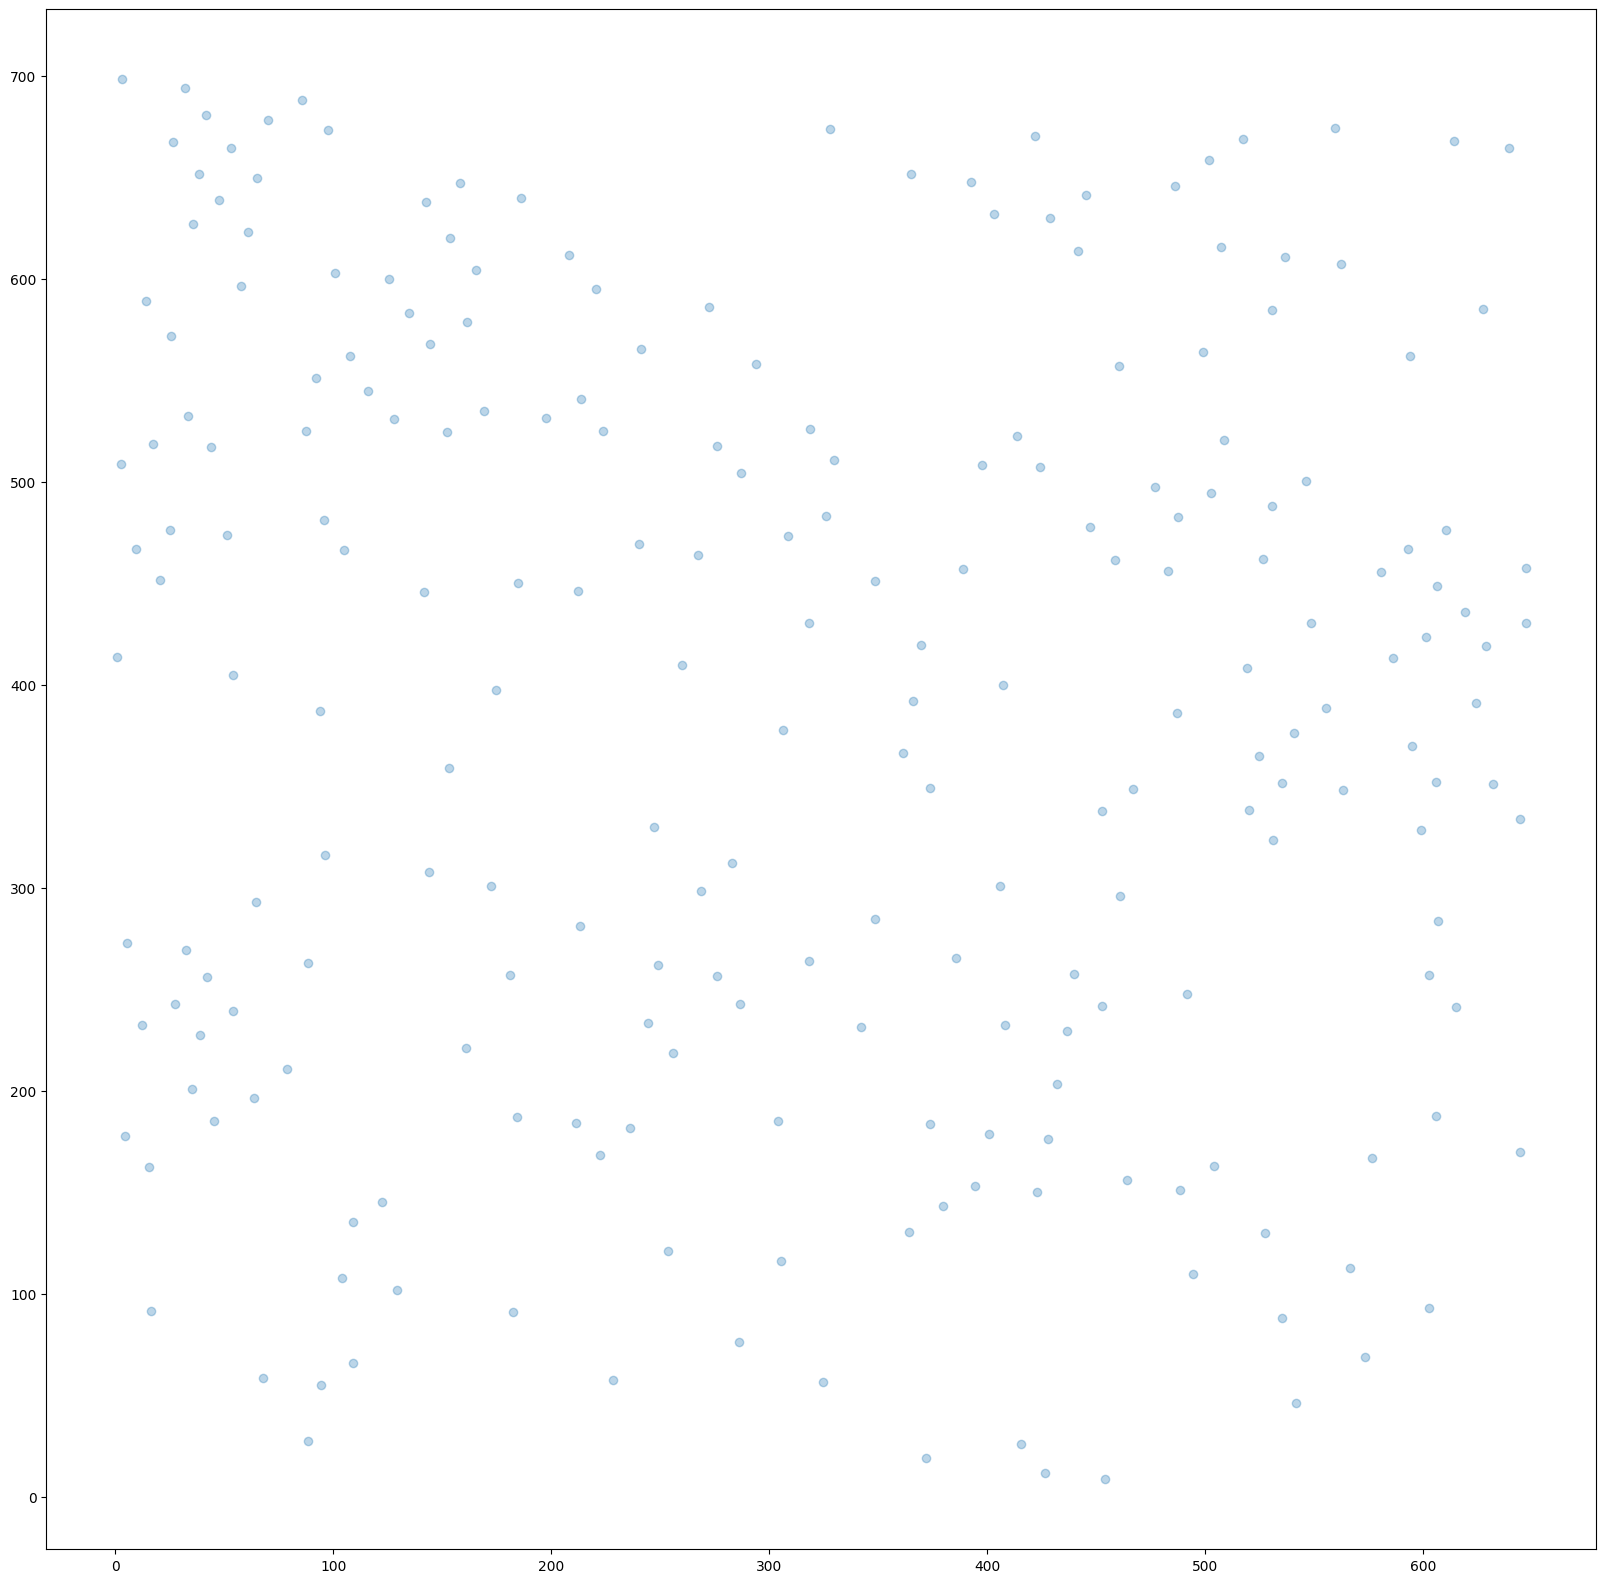

In [6]:
ax, fig = plt.subplots(figsize=(20,20))
plt.scatter(*new_centre_list.T, alpha=0.3)

In [7]:
print('Final number of centroids:', len(new_centre_list))

Final number of centroids: 228


In [8]:
def dot_in_tri(tri_coord, dot_, tol_angle=-1e-2, tol_dis=1e-3):
    
    dot = copy.deepcopy(dot_)
    # dot = np.concatenate((dot, dot_virtual), axis=0)
    t1, t2, t3 = tri_coord
    t1x, t1y, t2x, t2y, t3x, t3y = t1[0], t1[1], t2[0], t2[1], t3[0], t3[1]
    tri_bond_vector = np.array([t2-t1, t1-t3, t3-t2]) #* means the vertex is t3, t2, t1
    tri_bond_vector = tri_bond_vector/np.linalg.norm(tri_bond_vector, axis=1).reshape(-1,1)

    #* Projection of dot on each bond
    proj_coord_t1 = np.dot(dot-t1, tri_bond_vector[0])*tri_bond_vector[0] + t1
    inner_dot_t3 = np.dot(proj_coord_t1-dot, proj_coord_t1-t3)
    proj_len_1 = np.linalg.norm(dot-proj_coord_t1) #* t1-t2
    if proj_len_1 < tol_dis and np.min([t1x, t2x]) < dot[0] < np.max([t1x, t2x]) and np.min([t1y, t2y]) < dot[1] < np.max([t1y, t2y]):
        return True

    proj_coord_t3 = np.dot(dot-t3, tri_bond_vector[1])*tri_bond_vector[1] + t3
    inner_dot_t2 = np.dot(proj_coord_t3-dot, proj_coord_t3-t2)
    proj_len_2 = np.linalg.norm(dot-proj_coord_t3) #* t1-t3
    if proj_len_2 < tol_dis and np.min([t1x, t3x]) < dot[0] < np.max([t1x, t3x]) and np.min([t1y, t3y]) < dot[1] < np.max([t1y, t3y]):
        return True

    proj_coord_t2 = np.dot(dot-t2, tri_bond_vector[2])*tri_bond_vector[2] + t2
    inner_dot_t1 = np.dot(proj_coord_t2-dot, proj_coord_t2-t1)
    proj_len_3 = np.linalg.norm(dot-proj_coord_t2) #* t2-t3

    if proj_len_3 < tol_dis and np.min([t2x, t3x]) < dot[0] < np.max([t2x, t3x]) and np.min([t2y, t3y]) < dot[1] < np.max([t2y, t3y]):
        return True
    
    #TODO determine the threshold for inner product
    elif np.min([inner_dot_t1, inner_dot_t2, inner_dot_t3]) > tol_angle:
        return True
    else:
        return False
    
def c2_dot(dot, vec_vertices):
    ''' 
    return v' which is the dot after C2 operation
    '''
    v1, v2 = vec_vertices
    dot_c2 = v2 - (dot-v1)
    return dot_c2
    
l_range = np.array([10, 80]) #TODO lower and upper bounds for polygons, defined in above cell.
# l_range = np.array([12, 52])

theta_para_1_50 = 53.13/180*np.pi
theta_para_1_130 = 126.87/180*np.pi

theta_para_2_35 = 36.87/180*np.pi
theta_para_2_145 = 143.13/180*np.pi

square_para = 0.5*np.pi
threshold_length = 3 #TODO threshold for length difference
threshold_angle = 3
allow_dot_in_pattern = False #TODO allow dot in polygon, always False
# para_ind, square_ind = np.empty((0,2,2)), np.empty((0,2,2))
# img_ind = '01'
#! IF needed, determine the INDEX
# img_denote = '-filter2'
# new_centre_list = np.load(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted{img_denote}.npy')[:,-2:]
# new_centre_list = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw.npy')
# pth_load = f'{img_ind}{img_denote}{split_ind}.bmp'
# pth_load = '/media/wz/7AD631A4D6316195/Projects/SRO_related/CrCoNi-231101/1/1-filter2.bmp'
pth_load = f'demo/{img_ind}{img_denote}{split_ind}.bmp'
img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)

#TODO load calibrated points
# new_centre_list = np.load('/media/wz/7AD631A4D6316195/Projects/SRO_related/ogata/6/grid_calib/vec_space.npy')[:,-2:]

load_dismat = False
if load_dismat:
    dis_matrix = np.load(f'{img_ind}_dis_matrix.npy')
else:
    
    #* Use multi-processing to generate distance matrix 
    def main(i):
        i1, i2 = combinatorial_ind[i]
        dis = np.linalg.norm(new_centre_list[i1]-new_centre_list[i2])
        return dis

    combinatorial_ind = np.array(list(product(range(len(new_centre_list)), repeat=2)))
    n_core = 10 #* number of cores
    with mp.Pool(n_core) as p:
        dis_list_raw = np.array(p.map(main, range(combinatorial_ind.shape[0])))

    dis_matrix = np.zeros((len(new_centre_list), len(new_centre_list)))
    dis_matrix[combinatorial_ind[:,0], combinatorial_ind[:,1]] = dis_list_raw
    # dis_matrix[combinatorial_ind[:,1], combinatorial_ind[:,0]] = dis_list_raw

    print('Finish dis_matrix')

grid_interval = np.max(l_range)
grid_num = int(np.ceil(np.max(img.shape)/grid_interval))
# grid_num = 3 #* prefer not to specify it unless accuracy issue.
grid_x = np.linspace(0, img.shape[0], grid_num)
grid_y = np.linspace(0, img.shape[1], grid_num)
grid = np.array(list(product(grid_x, grid_y)))

mega_grid_interval = grid_interval*2
mega_grid_num = int(np.ceil(np.max(img.shape)/mega_grid_interval))
# mega_grid_num = 2 #* prefer not to specify it unless accuracy issue.
mega_grid_x = np.linspace(0, img.shape[0], mega_grid_num)
mega_grid_y = np.linspace(0, img.shape[1], mega_grid_num)
mega_grid = np.array(list(product(mega_grid_x, mega_grid_y)))

#* find the nearest megagrid for each grid and make a map
map_grid2mega = [None]*len(grid)
for i in range(len(grid)):
    dis = np.linalg.norm(mega_grid-grid[i], axis=1)
    ind = np.argsort(dis)[:4]
    map_grid2mega[i] = ind

#* Seperate the centre_list into NxN parts
centre_grids = [[] for _ in range(len(grid))]
centre_megagrids = [[] for _ in range(len(mega_grid))]
for i in range(len(new_centre_list)):
    centre_ = new_centre_list[i]
    dis = np.linalg.norm(grid-centre_, axis=1)
    valid_zone = np.where(dis <= np.max(l_range)*np.sqrt(2))[0]
    for j in valid_zone:
        centre_grids[j].append(i)
        for k in range(4):
            centre_megagrids[map_grid2mega[j][k]].append(i)

#! brutely define ONE SINGLE GRID!
# centre_grids = [np.arange(len(new_centre_list)).tolist()]
# centre_megagrids = centre_grids.copy()

def angle_calc(a, b):
    return np.arccos(np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b)))

ind_map = {
    (0,1): [[1,0],[2,0]],
    (0,2): [[0,1],[2,1]],
    (1,2): [[0,2],[1,2]],
}

diff_bond_map = {
    0: [0,1],
    1: [0,2],
    2: [1,2],
}
      
#* Find the triangle config
count = 0
range_stop, length_stop, angle_stop, angle_buffer = 0, 0, 0, []
range_buffer, length_buffer = [], []
valid_length_buffer, valid_length_buffer_square = [], []
debug = False
if debug:
    centre_grids = centre_grids[:1000] 
    
def main_pattern_deduce(count):
    
    para_ind_35_true, para_ind_50_true, square_ind_true = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
    para_ind_35_virtual, para_ind_50_virtual, square_ind_virtual = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
    orient_35, orient_50, orient_square = [], [], []
    virtual_centre_list = np.empty((0,2))
    
    c_grid = centre_grids[count]
    # mega_c_grid = np.unique(np.concatenate([np.array(centre_megagrids[i]) for i in map_grid2mega[count]])).astype(int)
    for i, j, k in combinations(c_grid, 3):
        
        ijk_ind = np.array([i,j,k])
        dis_list = [dis_matrix[i,j], dis_matrix[i,k], dis_matrix[j,k]]
        bond_discrimitive = np.array([
            np.prod(np.sign(dis_list[_]-l_range)) for _ in range(len(dis_list))
        ])
        
        ind_validbond = np.where(np.abs(bond_discrimitive+1)<1e-2)[0]
        #* Filter for range
        if len(ind_validbond) < 2:
            if debug:
                range_stop += 1
                range_buffer.append(dis_list)
            continue 
        
        #* Filter for equal length 
        dis_diff = np.abs(np.array([dis_list[d_i]-dis_list[d_j] for d_i, d_j in combinations(range(len(dis_list)), 2)]))
        ind_validlength = np.where(dis_diff < threshold_length)[0] #* Only one bond pair can be identical in length
        
        if len(ind_validlength) < 1:
            if debug:
                length_stop += 1
                length_buffer.append(dis_list)
            continue

        #! modified
        ri, rj, rk = new_centre_list[i], new_centre_list[j], new_centre_list[k]
        # if len(ind_validlength) > 1:
            
        angle_list_temp = np.rad2deg([
            angle_calc(rj-ri, rk-ri),
            angle_calc(ri-rj, rk-rj),
            angle_calc(ri-rk, rj-rk),
        ])
        
        rji = (rj-ri)/np.linalg.norm(rj-ri)
        rki = (rk-ri)/np.linalg.norm(rk-ri)
        rij = (ri-rj)/np.linalg.norm(ri-rj)
        rkj = (rk-rj)/np.linalg.norm(rk-rj)
        rik = (ri-rk)/np.linalg.norm(ri-rk)
        rjk = (rj-rk)/np.linalg.norm(rj-rk)
        
        if np.max(angle_list_temp) < 80:
        
            ind_validlength = [np.argmax([
                rji@rki, rij@rkj, rik@rjk
            ])]
            
        else:
            ind_validlength = [np.argmin([
                rji@rki, rij@rkj, rik@rjk
            ])]

        # if len(ind_validlength) > 1:
        #     ind_validlength = [np.argmin(dis_diff)]

        #* Filter for angle
        ind_map_ = ind_map[tuple(diff_bond_map[ind_validlength[0]])]
        bond_1, bond_2 = ind_map_[0], ind_map_[1]
        
        angle = angle_calc(new_centre_list[ijk_ind[bond_1[0]]]-new_centre_list[ijk_ind[bond_1[1]]], 
                    new_centre_list[ijk_ind[bond_2[0]]]-new_centre_list[ijk_ind[bond_2[1]]])
        
        area_cross = np.cross(new_centre_list[ijk_ind[bond_1[0]]]-new_centre_list[ijk_ind[bond_1[1]]], 
                    new_centre_list[ijk_ind[bond_2[0]]]-new_centre_list[ijk_ind[bond_2[1]]])

        for angle in [angle%np.pi, np.pi-angle%np.pi]:

            vertex_ind = new_centre_list[ijk_ind[bond_1[1]]] #* Vertex for equal-length bond
            bot_ind = new_centre_list[np.array([ijk_ind[bond_1[0]], ijk_ind[bond_2[0]]])]
            vertex_2nd = c2_dot(vertex_ind, bot_ind)
            
            tri_coords_1, tri_coord_2 = \
                np.concatenate((vertex_ind.reshape(1,-1), bot_ind), axis=0), \
                np.concatenate((vertex_2nd.reshape(1,-1), bot_ind), axis=0)
                
            sav_coord = np.array([
                [vertex_ind, bot_ind[0]],
                [vertex_ind, bot_ind[1]],
                [vertex_2nd, bot_ind[0]],
                [vertex_2nd, bot_ind[1]],
            ])
            
            vec_coord = 1/2*(bot_ind[0]+bot_ind[1])-vertex_ind
                    
            #TODO threshold for angle
            #? 50
            if (np.rad2deg(np.abs(angle-theta_para_1_50)) < threshold_angle 
                and np.max(dis_list) < 44
                and np.min(dis_list) > 34):

                # print(new_centre_list[[i,j,k]])

                tri_ind = np.array([[i,j],[i,k],[j,k]])
                #* Check if any dot in the triangle, if so, remove it
                # tri_coords = new_centre_list[ijk_ind]
                dot_in_tri_list = []
                
                if not allow_dot_in_pattern:
                    # for i_dot in mega_c_grid:
                    for i_dot in range(len(new_centre_list)):
                        if i_dot in ijk_ind:
                            continue
                        
                        for tri_coords in [
                                            tri_coords_1, 
                                            tri_coord_2
                                            ]:
                            dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                                new_centre_list[i_dot]))
                    
                    if np.sum(dot_in_tri_list) > 0:
                        continue
                            
                para_ind_50_true = np.concatenate([para_ind_50_true, sav_coord[:2]], axis=0)
                para_ind_50_virtual = np.concatenate([para_ind_50_virtual, sav_coord[2:]], axis=0)
                orient_50.append(vec_coord)
                virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)
                
                valid_length_buffer.append(dis_list)
            
            #? 130
            if (np.rad2deg(np.abs(angle-theta_para_1_130)) < threshold_angle 
                and np.max(dis_list) > 73
                and 40 < np.min(dis_list) < 44):
                            
                # vertex_ind = new_centre_list[ijk_ind[bond_1[1]]] #* Vertex for equal-length bond
                # bot_ind = new_centre_list[np.array([ijk_ind[bond_1[0]], ijk_ind[bond_2[0]]])]
                # vertex_2nd = c2_dot(vertex_ind, bot_ind)
                # tri_coords_1, tri_coord_2 = \
                #     np.concatenate((vertex_ind.reshape(1,-1), bot_ind), axis=0), \
                #     np.concatenate((vertex_2nd.reshape(1,-1), bot_ind), axis=0)
                
                tri_ind = np.array([[i,j],[i,k],[j,k]])
                #* Check if any dot in the triangle, if so, remove it
                # tri_coords = new_centre_list[ijk_ind]
                dot_in_tri_list = []
                
                if not allow_dot_in_pattern:
                    # for i_dot in mega_c_grid:
                    for i_dot in range(len(new_centre_list)):
                        if i_dot in ijk_ind:
                            continue
                        
                        for tri_coords in [
                                            tri_coords_1, 
                                            tri_coord_2
                                            ]:
                            dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                                new_centre_list[i_dot]))
                
                    if np.sum(dot_in_tri_list) > 0:
                        continue
                            
                para_ind_50_true = np.concatenate([para_ind_50_true, sav_coord[:2]], axis=0)
                para_ind_50_virtual = np.concatenate([para_ind_50_virtual, sav_coord[2:]], axis=0)
                orient_50.append(vec_coord)
                virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)

                valid_length_buffer.append(dis_list)
                
            #? 35
            if (np.rad2deg(np.abs(angle-theta_para_2_35)) < threshold_angle
                and np.max(dis_list) < 44
                and np.min(dis_list) > 23):
                
                tri_ind = np.array([[i,j],[i,k],[j,k]])
                #* Check if any dot in the triangle, if so, remove it
                # tri_coords = new_centre_list[ijk_ind]
                dot_in_tri_list = []
                inner_dot_ind = [] #! for debug
                if not allow_dot_in_pattern:
                    # for i_dot in mega_c_grid:
                    for i_dot in range(len(new_centre_list)):
                        if i_dot in ijk_ind:
                            continue
                        
                        for tri_coords in [
                                            tri_coords_1, 
                                            tri_coord_2
                                            ]:
                            dot_in_tri_ = dot_in_tri(tri_coords, new_centre_list[i_dot])
                            dot_in_tri_list.append(dot_in_tri_)
                            if dot_in_tri_:
                                inner_dot_ind.append(i_dot)
                    
                    if np.sum(dot_in_tri_list) > 0:
                        # print('dot in tri', inner_dot_ind, [tri_coords_1, tri_coord_2])
                        continue
                            
                para_ind_35_true = np.concatenate([para_ind_35_true, sav_coord[:2]], axis=0)
                para_ind_35_virtual = np.concatenate([para_ind_35_virtual, sav_coord[2:]], axis=0)
                orient_35.append(vec_coord)
                virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)

                valid_length_buffer.append(dis_list)
                
            #? 145
            if (np.rad2deg(np.abs(angle-theta_para_2_145)) < threshold_angle 
                and np.min(dis_list) < 44
                and np.max(dis_list) > 77):
                            
                tri_ind = np.array([[i,j],[i,k],[j,k]])
                #* Check if any dot in the triangle, if so, remove it
                # tri_coords = new_centre_list[ijk_ind]
                dot_in_tri_list = []
                
                if not allow_dot_in_pattern:
                    # for i_dot in mega_c_grid:
                    for i_dot in range(len(new_centre_list)):
                        if i_dot in ijk_ind:
                            continue
                        
                        for tri_coords in [
                                            tri_coords_1, 
                                            tri_coord_2
                                            ]:
                            dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                                new_centre_list[i_dot]))
                    
                    if np.sum(dot_in_tri_list) > 0:
                        continue
                            
                para_ind_35_true = np.concatenate([para_ind_35_true, sav_coord[:2]], axis=0)
                para_ind_35_virtual = np.concatenate([para_ind_35_virtual, sav_coord[2:]], axis=0)
                orient_35.append(vec_coord)
                virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)
                
                valid_length_buffer.append(dis_list)
            
            #? Square
            if (np.rad2deg(np.abs(angle-square_para)) < threshold_angle 
            #! modify?
                and 63 > np.max(dis_list) > 57
                and 40 < np.min(dis_list) < 44
                # and 300 < area_cross < 423
                ):
                
                tri_ind = np.array([[i,j],[i,k],[j,k]])
                # print(tri_ind)
                #* Check if any dot in the triangle, if so, remove it
                dot_in_tri_list = []
                
                if not allow_dot_in_pattern:
                    # for i_dot in mega_c_grid:
                    for i_dot in range(len(new_centre_list)):
                        if i_dot in ijk_ind:
                            continue
                        
                        for tri_coords in [
                                            tri_coords_1, 
                                            tri_coord_2
                                            ]:
                            dot_in_tri_list.append(dot_in_tri(tri_coords, 
                                                new_centre_list[i_dot]))
                            
                    #? precious lesson: tolerance for square should be as low as possible
                    
                    if np.sum(dot_in_tri_list) > 0:
                        continue
                
                square_ind_true = np.concatenate([square_ind_true, sav_coord[:2]], axis=0)
                square_ind_virtual = np.concatenate([square_ind_virtual, sav_coord[2:]], axis=0)
                orient_square.append(vec_coord)
                virtual_centre_list = np.concatenate([virtual_centre_list, vertex_2nd.reshape(1,-1)], axis=0)
                
                # #* Add information of orientation
                # if len(orient_square) == 0:
                #     orient_square.append(vec_coord)
                #     vec_square_mean = vec_coord
                    
                # elif len(orient_square) > 0:

                #     #* append the vector which is closest to the existing ones
                #     vec_coord_90rotate_1 = np.array([vec_coord[1], -vec_coord[0]])
                #     vec_coord_90rotate_2 = np.array([-vec_coord[1], vec_coord[0]])
                #     vec_coord_buffer = np.array([vec_coord, -vec_coord, vec_coord_90rotate_1, vec_coord_90rotate_2])
                #     vec_chosen = vec_coord_buffer[np.argmin(np.linalg.norm(vec_square_mean-vec_coord_buffer, axis=1))]
                #     orient_square.append(vec_chosen)
                #     vec_square_mean = np.mean(orient_square, axis=0)

                # valid_length_buffer_square.append(dis_list)
                
            else:
                angle_buffer.append(angle)
                # angle_stop += 1      

    #* search for hexagon-surrounded pair 
    hex_pair_true = np.empty((0, 2, 2))
    low_p, high_p = 17,20
    for i, j in combinations(c_grid, 2):
        dis_ = dis_matrix[i,j]
        if (dis_ < low_p) or (dis_ > high_p):
            continue
        
        ai, aj = new_centre_list[i], new_centre_list[j]
        res_i, res_j = np.linalg.norm(new_centre_list-ai, axis=1), np.linalg.norm(new_centre_list-aj, axis=1)
        valid_i, valid_j = np.where((low_p < res_i) & (high_p > res_i)), np.where((low_p < res_j) & (high_p > res_j))
        if len(valid_i[0]) > 2 or len(valid_j[0]) > 2 or len(valid_i[0])+len(valid_j[0]) > 3:
            continue
        
        hex_pair_true = np.concatenate((hex_pair_true, 
                                        np.array([[new_centre_list[i], new_centre_list[j]]])), axis=0)
            
    # count += 1
    # if count % 100 == 0: 
    #     clear_output(wait=True)
    #     print(f'{np.round(count/len(centre_grids)*100, 1)}% finished')
        
    return square_ind_true, para_ind_35_true, para_ind_50_true, \
        square_ind_virtual, para_ind_35_virtual, para_ind_50_virtual, \
        np.array(orient_35), np.array(orient_50), np.array(orient_square), \
        virtual_centre_list, hex_pair_true

n_core = 54 #* number of cores
with mp.Pool(n_core) as p:
    result_ind = p.map(main_pattern_deduce, range(len(centre_grids)))
    
para_ind_35_true, para_ind_50_true, square_ind_true = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
para_ind_35_virtual, para_ind_50_virtual, square_ind_virtual = np.empty((0,2,2)), np.empty((0,2,2)), np.empty((0,2,2))
orient_35, orient_50, orient_square = np.empty((0,2)), np.empty((0,2)), np.empty((0,2))
virtual_centre_list = np.empty((0,2))
hex_1_true, hex_2_true = np.empty((0,5,2)), np.empty((0,5,2))
hex_pair_true = np.empty((0,2,2))

for i in result_ind:
    square_i_t, para_35_i_t, para_50_i_t, \
    square_i_v, para_35_i_v, para_50_i_v, \
    orient_35_i, orient_50_i, orient_square_i, \
    virtual_i, hex_pair_i = i
    
    if len(square_i_t) > 0:
        square_ind_true = np.concatenate([square_ind_true, square_i_t], axis=0)
        square_ind_virtual = np.concatenate([square_ind_virtual, square_i_v], axis=0)
        orient_square = np.concatenate([orient_square, orient_square_i], axis=0)
    if len(para_35_i_t) > 0:
        para_ind_35_true = np.concatenate([para_ind_35_true, para_35_i_t], axis=0)
        para_ind_35_virtual = np.concatenate([para_ind_35_virtual, para_35_i_v], axis=0)
        orient_35 = np.concatenate([orient_35, orient_35_i], axis=0)
    if len(para_50_i_t) > 0:
        para_ind_50_true = np.concatenate([para_ind_50_true, para_50_i_t], axis=0)
        para_ind_50_virtual = np.concatenate([para_ind_50_virtual, para_50_i_v], axis=0)
        orient_50 = np.concatenate([orient_50, orient_50_i], axis=0)
        
    if len(virtual_i) > 0:
        virtual_centre_list = np.concatenate([virtual_centre_list, virtual_i], axis=0)
        
    # if len(hex_1_i) > 0:
    #     hex_1_true = np.concatenate([hex_1_true, hex_1_i], axis=0)
    # if len(hex_2_i) > 0:
    #     hex_2_true = np.concatenate([hex_2_true, hex_2_i], axis=0)
    
    if len(hex_pair_i) > 0:
        hex_pair_true = np.concatenate([hex_pair_true, hex_pair_i], axis=0)


Finish dis_matrix


In [ ]:
def dot_in_tri(tri_coord, dot_, tol_angle=-1e-2, tol_dis=1e-2):
   
   dot = copy.deepcopy(dot_)
   # dot = np.concatenate((dot, dot_virtual), axis=0)
   t1, t2, t3 = tri_coord
   t1x, t1y, t2x, t2y, t3x, t3y = t1[0], t1[1], t2[0], t2[1], t3[0], t3[1]
   tri_bond_vector = np.array([t2-t1, t1-t3, t3-t2]) #* means the vertex is t3, t2, t1
   tri_bond_vector = tri_bond_vector/np.linalg.norm(tri_bond_vector, axis=1).reshape(-1,1)

   #* Projection of dot on each bond
   proj_coord_t1 = np.dot(dot-t1, tri_bond_vector[0])*tri_bond_vector[0] + t1
   inner_dot_t3 = np.dot(proj_coord_t1-dot, proj_coord_t1-t3)
   proj_len_1 = np.linalg.norm(dot-proj_coord_t1) #* t1-t2
   if proj_len_1 < tol_dis and np.min([t1x, t2x]) < dot[0] < np.max([t1x, t2x]) and np.min([t1y, t2y]) < dot[1] < np.max([t1y, t2y]):
       return True

   proj_coord_t3 = np.dot(dot-t3, tri_bond_vector[1])*tri_bond_vector[1] + t3
   inner_dot_t2 = np.dot(proj_coord_t3-dot, proj_coord_t3-t2)
   proj_len_2 = np.linalg.norm(dot-proj_coord_t3) #* t1-t3
   if proj_len_2 < tol_dis and np.min([t1x, t3x]) < dot[0] < np.max([t1x, t3x]) and np.min([t1y, t3y]) < dot[1] < np.max([t1y, t3y]):
       return True

   proj_coord_t2 = np.dot(dot-t2, tri_bond_vector[2])*tri_bond_vector[2] + t2
   inner_dot_t1 = np.dot(proj_coord_t2-dot, proj_coord_t2-t1)
   proj_len_3 = np.linalg.norm(dot-proj_coord_t2) #* t2-t3

   if proj_len_3 < tol_dis and np.min([t2x, t3x]) < dot[0] < np.max([t2x, t3x]) and np.min([t2y, t3y]) < dot[1] < np.max([t2y, t3y]):
       return True
   
   #TODO determine the threshold for inner product
   elif np.min([inner_dot_t1, inner_dot_t2, inner_dot_t3]) > tol_angle:
       return True
   else:
       return False

def rot_mat(theta):
   return np.array([
       [np.cos(theta), -np.sin(theta)],
       [np.sin(theta), np.cos(theta)],
   ])

def mat_permute(mat):
   mat_buffer = []
   for comb_ind in permutations(range(len(mat)), len(mat)):
       mat_buffer.append([mat[i] for i in comb_ind])
       
   return np.array(mat_buffer)

def mat_similar(mat_groundtruth, mat, atol=1e-3):
   mat_buffer = mat_permute(mat)
   mat_gt_square = mat_groundtruth@mat_groundtruth.T
   for mat_ in mat_buffer:
       mat_square = mat_@mat_.T
       sim_mat =  np.allclose(mat_gt_square, mat_square,
                              atol=atol)
       if sim_mat:
           break 
       
   return sim_mat

def mat_identical(mat_gt, mat, atol=1e-3):
   mat_buffer = mat_permute(mat)
   similar = False
   for mat_ in mat_buffer:
       if np.allclose(mat_gt, mat_, atol=atol):
           similar = True 
           break 
   
   return similar

def para_renorm(para_t, para_v, atol):
   len_paraind = len(para_t)
   mat_validbuffer = []
   para_validind = []
   for i in range(len_paraind//2):
       p1t, p2t, p1v, p2v = para_t[2*i], \
           para_t[2*i+1], \
           para_v[2*i], \
           para_v[2*i+1]
           
       p = np.concatenate((p1t, p2t, p1v, p2v), axis=0)
       p = np.unique(p, axis=0) #* 4-dot
       
       sim_mat = False
       for mat in mat_validbuffer:
           if mat_identical(mat, p, atol=atol):
               sim_mat = True 
               break
       
       if not sim_mat:
           mat_validbuffer.append(p)
           para_validind.append(i)
   
   para_validind = np.array(para_validind).astype(int)
   num_poly = len(para_validind)
   para_validind = np.array([[2*i, 2*i+1] for i in para_validind]).flatten()
   para_t_valid = para_t[para_validind]
   para_v_valid = para_v[para_validind]
   
   return para_t_valid, para_v_valid, num_poly
 
# img_denote_sav = '_dotted-Zn2_03'
# split_ind = '_binaryfilter_115_255_255' #TODO define the split index
allow_dot_in_pattern = False #TODO allow dot in polygon, always False


pth_load = f'demo/{img_ind}{img_denote}{split_ind}.bmp'
img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay = img_color.copy()
alpha = 0.1

def trip_make(para_ind):
   tri_list = []
   for i in range(len(para_ind//2)):
       ind_para_ = np.unique(np.concatenate((
           para_ind[2*i], para_ind[2*i+1]
       )).reshape(-1,2), axis=0)
       tri_list.append(ind_para_)
   
   return tri_list

#* ==========================polygon puring==========================
#TODO count the valid polygons
def tri_mat_make(para_t, para_v):
   len_para = len(para_t)
   tri_mat = []
   for i in range(len_para//2):
       p1t, p2t, p1v, p2v = para_t[2*i], \
           para_t[2*i+1], \
           para_v[2*i], \
           para_v[2*i+1]
           
       tri_t = np.unique(np.concatenate(np.array([p1t, p2t]), axis=0), axis=0) #* 3x2 matrix
       tri_v = np.unique(np.concatenate(np.array([p1v, p2v]), axis=0), axis=0) #* 3x2 matrix
       
       tri_mat.append([tri_t, tri_v])
   
   return tri_mat

def virt_buffer_make(para_v, count_v):
   return para_v[[2*i for i in range(count_v)]][:,0,:]


def valid_poly(para_t, para_v, virt_vert_buffer_all, allow_virtual=True):
    
    if allow_virtual:
        return para_t, para_v
    
    else:
        tri_mat = tri_mat_make(para_t, para_v)
        ind_array = np.arange(len(tri_mat))

        invalid_poly_ind = []
        tol_angle = 1 #TODO important to modify
        tol_dis = -1e-2
        for tri_i, bi_tri in enumerate(tri_mat):
            tri1, tri2 = bi_tri #* two tri. form a quad.
            
            for virt in virt_vert_buffer_all:
                if ((dot_in_tri(tri1, virt, tol_angle=tol_angle, tol_dis=tol_dis)) 
                    or (dot_in_tri(tri2, virt, tol_angle=tol_angle, tol_dis=tol_dis))):
                    invalid_poly_ind.append(tri_i)
                    break
                
        valid_poly_ind = np.setdiff1d(ind_array, np.array(invalid_poly_ind))
        valid_poly_ind = np.array([[2*i, 2*i+1] for i in valid_poly_ind]).flatten()
        
        para_t_valid = para_t[valid_poly_ind]
        para_v_valid = para_v[valid_poly_ind]
        
        return para_t_valid, para_v_valid

para_ind_50_true_valid, para_ind_50_virtual_valid, count_50 = para_renorm(para_ind_50_true, para_ind_50_virtual, atol=4)
para_ind_35_true_valid, para_ind_35_virtual_valid, count_35 = para_renorm(para_ind_35_true, para_ind_35_virtual, atol=4)
square_ind_true_valid, square_ind_virtual_valid, count_square = para_renorm(square_ind_true, square_ind_virtual, atol=4)

virt_vert_buffer_all = np.concatenate((
   virt_buffer_make(para_ind_50_virtual_valid, count_50),
   virt_buffer_make(para_ind_35_virtual_valid, count_35),
   virt_buffer_make(square_ind_virtual_valid, count_square)), axis=0)
     
#TODO allow virtual vertex in the polygon?
allow_virtual_vertex = True
para_ind_50_true, para_ind_50_virtual = \
   valid_poly(para_ind_50_true_valid, para_ind_50_virtual_valid, virt_vert_buffer_all,
              allow_virtual_vertex)
para_ind_35_true, para_ind_35_virtual = \
   valid_poly(para_ind_35_true_valid, para_ind_35_virtual_valid, virt_vert_buffer_all,
              allow_virtual_vertex)   
square_ind_true, square_ind_virtual = \
   valid_poly(square_ind_true_valid, square_ind_virtual_valid, virt_vert_buffer_all,
              allow_virtual_vertex)

#* ==========================end polygon puring=========================


para_ind_35_t = np.unique(para_ind_35_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_35_v = np.unique(para_ind_35_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_50_t = np.unique(para_ind_50_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
para_ind_50_v = np.unique(para_ind_50_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
square_ind_t = np.unique(square_ind_true.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)
square_ind_v = np.unique(square_ind_virtual.reshape(-1,2,4), axis=0).reshape(-1,4).astype(int)

vertice_coord_all = np.concatenate((para_ind_35_t, para_ind_50_t, square_ind_t,
                                   para_ind_35_v, para_ind_50_v, square_ind_v), axis=0)


new_centre_list = np.round(new_centre_list, 0).astype(int)

#* Make bond tuples
with open(f'demo/num_figure.pickle', 'rb') as f:
   num_fig = pickle.load(f)
   
bond_square_v, bond_square_t = [], []
for i in range(len(square_ind_t)):
   bond_square_t.append(tuple(square_ind_t[i]))
   bond_square_v.append(tuple(square_ind_v[i]))

bond_para_35_v, bond_para_35_t = [], []    
for j in range(len(para_ind_35_t)):
   bond_para_35_t.append(tuple(para_ind_35_t[j]))
   bond_para_35_v.append(tuple(para_ind_35_v[j]))

bond_para_50_v, bond_para_50_t = [], []
for k in range(len(para_ind_50_t)):
   bond_para_50_t.append(tuple(para_ind_50_t[k]))
   bond_para_50_v.append(tuple(para_ind_50_v[k]))

c_para_35 = (255, 161, 7)
c_para_50 = (0, 223, 255)
c_square = (0, 0, 255)

line_thickness_t = 2
line_thickness_v = 2
atol = 4 #TODO tolerance for similarity criteria
# count_square, count_50, count_35 = 0, 0, 0
#* =================square=====================
bond_buffer = []
for bond_t, bond_v in zip(bond_square_t, bond_square_v):
   x1, y1, x2, y2 = bond_t
   x1_v, y1_v, x2_v, y2_v = bond_v
   
   mat_t = np.array([[x1, y1],[x2, y2]])
   mat_v = np.array([[x1_v, y1_v],[x2_v, y2_v]])
       
   sim_bond_t, sim_bond_v = False, False
   for bond in bond_buffer:
       if mat_identical(bond, mat_t, atol=atol):
           sim_bond_t = True
       
       if mat_identical(bond, mat_v, atol=atol):
           sim_bond_v = True
       
   if not sim_bond_t:
       bond_buffer.append(mat_t)
       cv2.line(img_color, (y1, x1), (y2, x2), c_square, line_thickness_t)
       
   if not sim_bond_v:
       bond_buffer.append(mat_v)
       cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_square, line_thickness_v)


#* ==============35======================= 
bond_buffer = []
for bond_t, bond_v in zip(bond_para_35_t, bond_para_35_v):
   x1, y1, x2, y2 = bond_t
   x1_v, y1_v, x2_v, y2_v = bond_v
   
   mat_t = np.array([[x1, y1],[x2, y2]])
   mat_v = np.array([[x1_v, y1_v],[x2_v, y2_v]])
       
   sim_bond_t, sim_bond_v = False, False
   for bond in bond_buffer:
       if mat_identical(bond, mat_t, atol=atol):
           sim_bond_t = True
       
       if mat_identical(bond, mat_v, atol=atol):
           sim_bond_v = True
       
   if not sim_bond_t:
       bond_buffer.append(mat_t)
       cv2.line(img_color, (y1, x1), (y2, x2), c_para_35, line_thickness_t)
       
   if not sim_bond_v:
       bond_buffer.append(mat_v)
       cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_para_35, line_thickness_v)
       

#* ===============50======================
bond_buffer = []  
for bond_t, bond_v in zip(bond_para_50_t, bond_para_50_v):
   x1, y1, x2, y2 = bond_t
   x1_v, y1_v, x2_v, y2_v = bond_v
   
   mat_t = np.array([[x1, y1],[x2, y2]])
   mat_v = np.array([[x1_v, y1_v],[x2_v, y2_v]])
       
   sim_bond_t, sim_bond_v = False, False
   for bond in bond_buffer:
       if mat_identical(bond, mat_t, atol=atol):
           sim_bond_t = True
       
       if mat_identical(bond, mat_v, atol=atol):
           sim_bond_v = True
       
   if not sim_bond_t:
       bond_buffer.append(mat_t)
       cv2.line(img_color, (y1, x1), (y2, x2), c_para_50, line_thickness_t)
       
   if not sim_bond_v:
       bond_buffer.append(mat_v)
       cv2.line(img_color, (y1_v, x1_v), (y2_v, x2_v), c_para_50, line_thickness_v)

img_color_raw = copy.deepcopy(img_color)
#* Draw dots 
radius = 2
thickness = 1
for (x, y) in new_centre_list:
   x, y =  int(round(x, 0)), int(round(y, 0))
   cv2.circle(img_color, (y,x), radius, (112,233,255), thickness)

#! hexagon part 
# hex_1_t_unic = np.unique(np.array([i[np.lexsort((i[:, 0],))] for i in hex_1_true]), axis=0)
# hex_2_t_unic = np.unique(np.array([i[np.lexsort((i[:, 0],))] for i in hex_2_true]), axis=0)

# for hex_ in hex_1_t_unic:
#     for (x, y) in hex_:
#         x, y =  int(round(x, 0)), int(round(y, 0))
#         cv2.circle(img_color, (y,x), 3, (127,255,212), thickness=2)

#! hexagon-surrounded pair
hex_pair_unic = np.unique(np.array([i[np.lexsort((i[:, 0],))] for i in hex_pair_true]), axis=0)
for hex_ in hex_pair_unic:
   (x1, y1), (x2, y2) = hex_.astype(int)
#    cv2.line(img_color, (y1, x1), (y2, x2), (172, 227, 254), 3)

num_fig["num_35"] += len(bond_para_35_t)
num_fig["num_50"] += len(bond_para_50_t)
num_fig["num_90"] += len(bond_square_t)

print('num of 35-tri: ', len(bond_para_35_t)/2)
print('num of 53-tri:', len(bond_para_50_t)/2)
print('num of square: ', len(bond_square_t)/2)

num_fig["num_pair"] += len(hex_pair_unic)
with open(f'demo/num_figure.pickle', 'wb') as f:
   pickle.dump(num_fig, f)

sav_denote = ''
if not allow_dot_in_pattern:
   sav_denote = '_pure_polygon'

tolerant_threshold = False  #* if use tolerant threshold
if tolerant_threshold:
   sav_denote += '_tolerant'

inv_filter = True #TODO if use inversed filtered points
if not inv_filter:
   img_type = '_real'
else:
   img_type='_inv'

cv2.addWeighted(overlay, alpha, img_color_raw, 1-alpha, 0, img_color_raw)
cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0, img_color)

cv2.imwrite(f'demo/{img_ind}_dotted_line_{sav_denote}{img_denote}{split_ind}{img_type}.bmp', img_color)
cv2.imwrite(f'demo/{img_ind}_dotted_line_raw_{sav_denote}{img_denote}{split_ind}{img_type}.bmp', img_color_raw)

print(f'demo/{img_ind}_dotted_line{sav_denote}{img_denote}{split_ind}{img_type}.bmp')

num of 35-tri:  20.0
num of 53-tri: 17.0
num of square:  9.0
demo/9_dotted_line_pure_polygon_dotted-raw_20_binaryfilter_175_255_255_inv.bmp
